In [16]:
#CODING PART FOR DATA PREPROCESSING AND EXRA FEATUES GENERATION

import pandas as pds
from google.colab import files

dataframe = pds.read_csv("/content/dataset-uncleaned.csv")

#Handling Missing Values and Remove Duplicates

for column in dataframe.columns:
    if dataframe[column].dtype in ['int64', 'float64']:
        dataframe[column] = dataframe[column].fillna(dataframe[column].mean())
    else:
        dataframe[column] = dataframe[column].fillna(dataframe[column].mode()[0])

dataframe.drop_duplicates(inplace=True)

#Age Groups

dataframe['age_group'] = pds.cut(
    dataframe['age'],
    bins=[15, 20, 25, 30, 40],
    labels=['Teen', 'Young Adult', 'Adult', 'Professional']
)

#Productivity Category

def get_productivity_level(score):
    if score <= 2:
        return "Low"
    elif score == 3:
        return "Medium"
    else:
        return "High"

dataframe['productivity_category'] = dataframe['procrastination_score'].apply(get_productivity_level)

#Work Efficiency Category

dataframe['completion_rate'] = dataframe['tasks_completed'] / (dataframe['tasks_planned'] + 1)

def get_efficiency_level(rate):
    if rate < 0.4:
        return "Low"
    elif rate < 0.7:
        return "Medium"
    else:
        return "High"

dataframe['work_efficiency_category'] = dataframe['completion_rate'].apply(get_efficiency_level)

#Stress Category

def get_stress_level(stress):
    if stress <= 3:
        return "Low"
    elif stress <= 6:
        return "Medium"
    else:
        return "High"

dataframe['stress_category'] = dataframe['stress_level'].apply(get_stress_level)

# Move procrastination_score to last column
target = 'procrastination_score'
cols = [col for col in dataframe.columns if col != target] + [target]
dataframe = dataframe[cols]

print("Final Dataset Shape:", dataframe.shape)
print("\nMissing Values:\n", dataframe.isnull().sum())
print("\nPreview:\n", dataframe.head())


dataframe.to_csv("processed_dataset.csv", index=False)

Final Dataset Shape: (4998, 18)

Missing Values:
 age                         0
sleep_hours                 0
tasks_planned               0
tasks_completed             0
focus_hours                 0
stress_level                0
motivation_level            0
task_interest               0
self_control                0
routine_consistency         0
peak_productivity_time      0
screen_time_minutes         0
age_group                   0
productivity_category       0
completion_rate             0
work_efficiency_category    0
stress_category             0
procrastination_score       0
dtype: int64

Preview:
    age  sleep_hours  tasks_planned  tasks_completed  focus_hours  \
0   22          8.6              4                3          7.1   
1   35          5.1              6                4          7.4   
2   30          6.1              4                3          5.4   
3   26          6.7              6                5          7.6   
4   23          5.2              4            


Random Forest Performance
MAE  : 0.2596
MSE  : 0.1380
RMSE : 0.3714
R2   : 0.9548


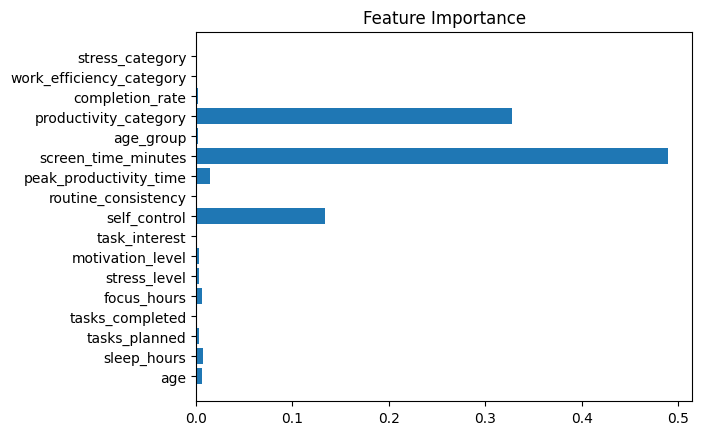

In [19]:
# Random Forest model for procrastination prediction

import pandas as pds
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
dataframe = pds.read_csv("processed_dataset.csv")

# Encode categorical columns
encoder = LabelEncoder()
for col in dataframe.select_dtypes(include='object').columns:
    dataframe[col] = encoder.fit_transform(dataframe[col])

# Split features and target
X = dataframe.drop('procrastination_score', axis=1)
y = dataframe['procrastination_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nRandom Forest Performance")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# Feature importance
importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()


SHAP analysis completed successfully

Generating SHAP Summary Plot...


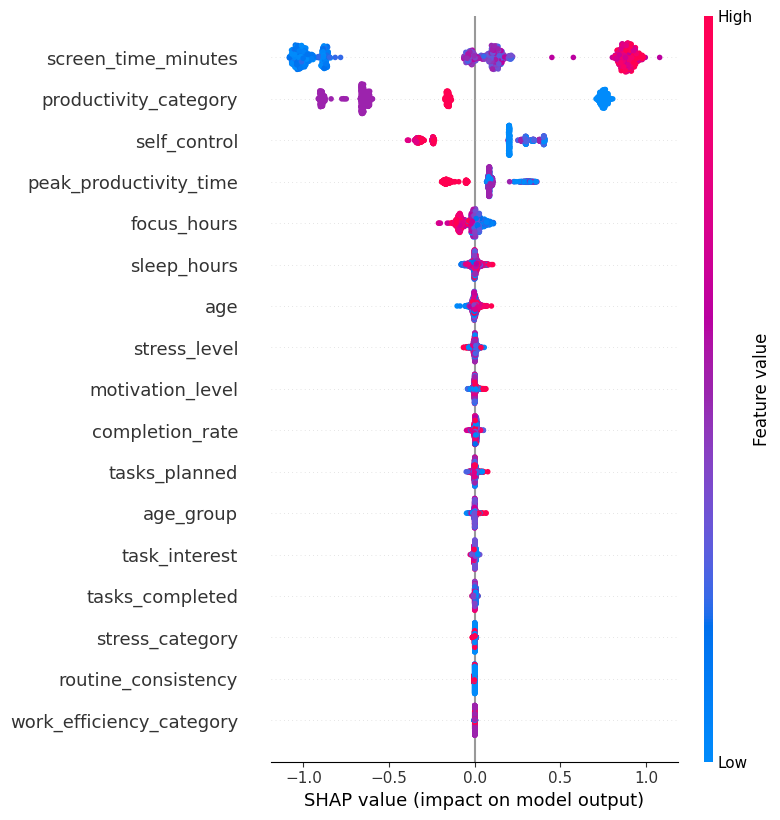


Generating SHAP Feature Importance Bar Plot...


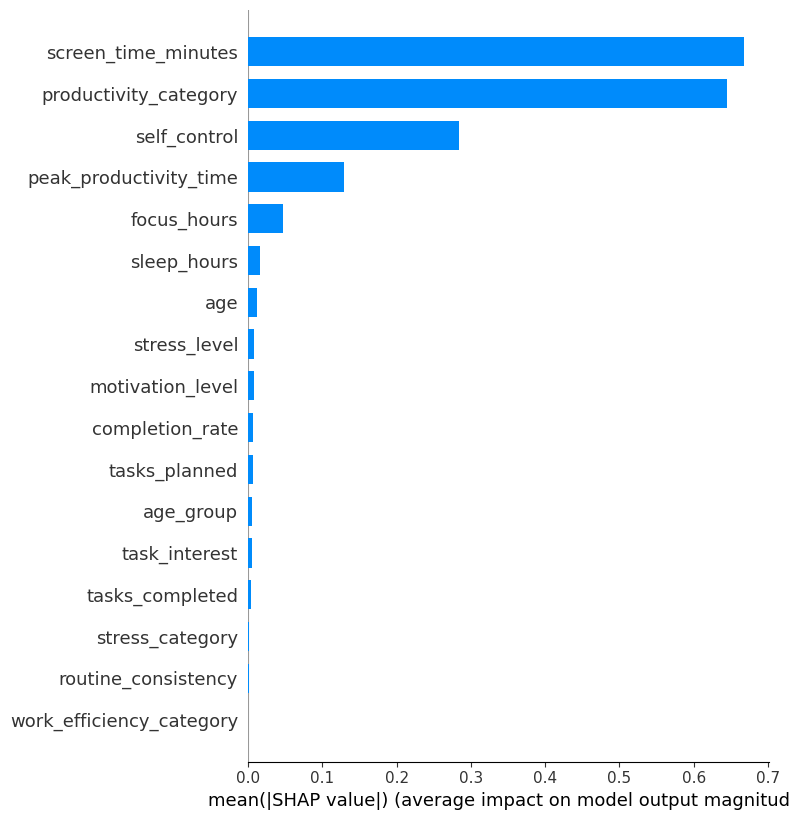


Generating SHAP Dependence Plot...


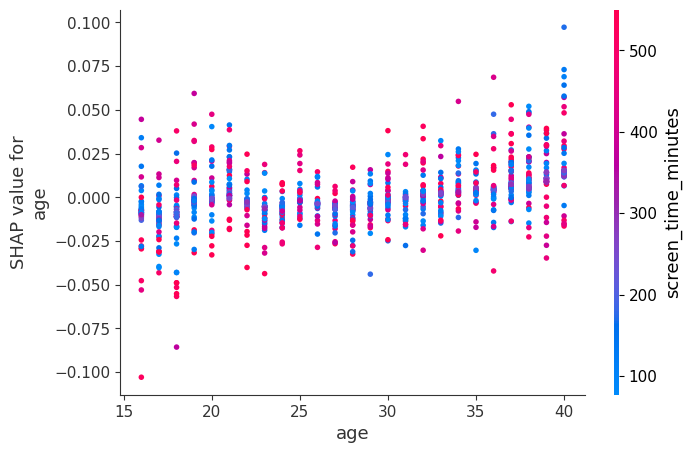


Most Influential Feature (SHAP): screen_time_minutes


In [18]:
# SHAP EXPLAINABILITY MODULE

import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("\nSHAP analysis completed successfully")

# feature importance
print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test)

# feature impact
print("\nGenerating SHAP Feature Importance Bar Plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# dependency plot
print("\nGenerating SHAP Dependence Plot...")
feature_name = X.columns[0]
shap.dependence_plot(feature_name, shap_values, X_test)

# Find most important feature
importance_values = np.abs(shap_values).mean(axis=0)
top_feature = X.columns[np.argmax(importance_values)]
print("\nMost Influential Feature (SHAP):", top_feature)

In [23]:
# PART 4: User input, prediction, and suggestions

import pandas as pd

# Take user input
def get_user_input():
    print("\n--- Procrastination Analysis Survey ---\n")

    user = {}
    user['age'] = int(input("Enter your age: "))
    user['sleep_hours'] = float(input("Sleep hours: "))
    user['tasks_planned'] = int(input("Tasks planned: "))
    user['tasks_completed'] = int(input("Tasks completed: "))
    user['focus_hours'] = float(input("Focus hours: "))
    user['stress_level'] = int(input("Stress level (1–10): "))
    user['motivation_level'] = int(input("Motivation level (1–10): "))
    user['task_interest'] = int(input("Task interest (1–5): "))
    user['self_control'] = int(input("Self-control (1–5): "))

    rc = input("Routine followed? (yes/no): ").lower()
    user['routine_consistency'] = 1 if rc == 'yes' else 0

    print("Peak productivity time: 0-Morning, 1-Afternoon, 2-Evening")
    user['peak_productivity_time'] = int(input("Enter choice: "))

    user['screen_time_minutes'] = int(input("Screen time (minutes): "))

    # derived feature
    user['completion_rate'] = user['tasks_completed'] / (user['tasks_planned'] + 1)

    return user


# Create missing features required by model
def prepare_user_input(user):

    if user['age'] <= 20:
        user['age_group'] = 'Teen'
    elif user['age'] <= 25:
        user['age_group'] = 'Young Adult'
    elif user['age'] <= 30:
        user['age_group'] = 'Adult'
    else:
        user['age_group'] = 'Professional'

    user['productivity_category'] = 'Medium'

    if user['completion_rate'] < 0.4:
        user['work_efficiency_category'] = 'Low'
    elif user['completion_rate'] < 0.7:
        user['work_efficiency_category'] = 'Medium'
    else:
        user['work_efficiency_category'] = 'High'

    if user['stress_level'] <= 3:
        user['stress_category'] = 'Low'
    elif user['stress_level'] <= 6:
        user['stress_category'] = 'Medium'
    else:
        user['stress_category'] = 'High'

    return user


# Predict procrastination score
def predict_procrastination(user_input, model, X_columns):

    user_input = prepare_user_input(user_input)
    input_df = pd.DataFrame([user_input])

    # encode categorical values
    for col in input_df.select_dtypes(include='object').columns:
        input_df[col] = input_df[col].astype('category').cat.codes

    # match training column order
    input_df = input_df.reindex(columns=X_columns, fill_value=0)

    prediction = model.predict(input_df)[0]
    return round(prediction, 2)


# Generate suggestions
def generate_suggestions(user):
    suggestions = []

    if user['sleep_hours'] < 6:
        suggestions.append("You are sleeping less than recommended. Try maintaining a fixed sleep schedule and aim for 7–8 hours to improve concentration and reduce fatigue.")

    if user['focus_hours'] < 3:
        suggestions.append("Your focus time is low. Try the Pomodoro technique (25 min work + 5 min break) to gradually improve deep work sessions.")

    if user['screen_time_minutes'] > 300:
        suggestions.append("High screen time is affecting productivity. Limit social media usage and consider using app blockers during work hours.")

    if user['stress_level'] > 6:
        suggestions.append("Your stress level is high. Include short breaks, physical activity, or mindfulness techniques like meditation to manage stress.")

    if user['motivation_level'] < 4:
        suggestions.append("Low motivation detected. Start with small, achievable tasks and reward yourself after completion to build momentum.")

    if user['tasks_completed'] < user['tasks_planned']:
        suggestions.append("You are not completing planned tasks. Break larger tasks into smaller steps and prioritize them using a to-do list.")

    if user['routine_consistency'] == 0:
        suggestions.append("Lack of routine can lead to procrastination. Try setting fixed time blocks for study, breaks, and rest.")

    if user['completion_rate'] < 0.5:
        suggestions.append("Your task completion rate is low. Focus on fewer tasks per day and ensure completion rather than over-planning.")

    if user['self_control'] < 3:
        suggestions.append("Low self-control detected. Remove distractions from your environment and keep your workspace minimal.")

    if user['task_interest'] < 3:
        suggestions.append("Low interest in tasks may cause delay. Try linking tasks to your goals or make them more engaging.")

    if len(suggestions) == 0:
        suggestions.append("Your habits look well balanced. Maintain consistency and continue your current routine.")

    return suggestions

# Main system
def run_system(model, X_columns):

    user = get_user_input()

    score = predict_procrastination(user, model, X_columns)
    suggestions = generate_suggestions(user)

    print("\n--- RESULT ---")
    print("Predicted Procrastination Score:", score)

    print("\nSuggestions:")
    for s in suggestions:
        print("-", s)


# Run (after Part 2)
X_columns = X.columns
run_system(model, X_columns)


--- Procrastination Analysis Survey ---

Enter your age: 18
Sleep hours: 2
Tasks planned: 10
Tasks completed: 1
Focus hours: 0.5
Stress level (1–10): 9
Motivation level (1–10): 1
Task interest (1–5): 1
Self-control (1–5): 1
Routine followed? (yes/no): no
Peak productivity time: 0-Morning, 1-Afternoon, 2-Evening
Enter choice: 3
Screen time (minutes): 300

--- RESULT ---
Predicted Procrastination Score: 3.52

Suggestions:
- You are sleeping less than recommended. Try maintaining a fixed sleep schedule and aim for 7–8 hours to improve concentration and reduce fatigue.
- Your focus time is low. Try the Pomodoro technique (25 min work + 5 min break) to gradually improve deep work sessions.
- Your stress level is high. Include short breaks, physical activity, or mindfulness techniques like meditation to manage stress.
- Low motivation detected. Start with small, achievable tasks and reward yourself after completion to build momentum.
- You are not completing planned tasks. Break larger task